Check embeddings 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist, squareform
from scipy.stats import normaltest, kurtosis, skew
import warnings
warnings.filterwarnings('ignore')

def analyze_dgi_embeddings(avg_embeddings, std_embeddings=None):
    """
    Comprehensive analysis of DGI embeddings (label-agnostic)
    
    Args:
        avg_embeddings: numpy array of shape (n_nodes, embedding_dim) - averaged embeddings
        std_embeddings: optional numpy array of same shape - std across runs
    """
    
    print("="*70)
    print("DGI EMBEDDING ANALYSIS")
    print("="*70)
    
    embeddings = avg_embeddings  # Use avg embeddings for main analysis
    n_nodes, embed_dim = embeddings.shape
    print(f"Embedding shape: {n_nodes} nodes × {embed_dim} dimensions")
    
    if std_embeddings is not None:
        print(f"Standard deviation embeddings also provided for stability analysis")
    
    # ============================================================================
    # 1. BASIC STATISTICS
    # ============================================================================
    print(f"\n{'='*50}")
    print("1. BASIC STATISTICS")
    print(f"{'='*50}")
    
    print(f"Mean embedding norm: {np.linalg.norm(embeddings, axis=1).mean():.4f}")
    print(f"Std embedding norm: {np.linalg.norm(embeddings, axis=1).std():.4f}")
    print(f"Min embedding norm: {np.linalg.norm(embeddings, axis=1).min():.4f}")
    print(f"Max embedding norm: {np.linalg.norm(embeddings, axis=1).max():.4f}")
    
    print(f"\nPer-dimension statistics:")
    print(f"Mean across dimensions: {embeddings.mean(axis=0).mean():.6f}")
    print(f"Std across dimensions: {embeddings.std(axis=0).mean():.6f}")
    print(f"Min value: {embeddings.min():.6f}")
    print(f"Max value: {embeddings.max():.6f}")
    
    # Check for near-zero dimensions
    dim_stds = embeddings.std(axis=0)
    near_zero_dims = np.sum(dim_stds < 1e-6)
    print(f"Near-zero variance dimensions: {near_zero_dims}/{embed_dim}")
    
    # Cross-run stability analysis if std_embeddings provided
    if std_embeddings is not None:
        print(f"\n--- CROSS-RUN STABILITY ANALYSIS ---")
        mean_std_per_node = np.mean(std_embeddings, axis=1)
        mean_std_per_dim = np.mean(std_embeddings, axis=0)
        
        print(f"Node stability (lower = more stable):")
        print(f"  Mean std across nodes: {mean_std_per_node.mean():.6f}")
        print(f"  Max std across nodes: {mean_std_per_node.max():.6f}")
        print(f"  Min std across nodes: {mean_std_per_node.min():.6f}")
        
        print(f"Dimension stability:")
        print(f"  Mean std across dimensions: {mean_std_per_dim.mean():.6f}")
        print(f"  Most unstable dimension std: {mean_std_per_dim.max():.6f}")
        print(f"  Most stable dimension std: {mean_std_per_dim.min():.6f}")
        
        # Identify most/least stable nodes
        most_stable_nodes = np.argsort(mean_std_per_node)[:5]
        least_stable_nodes = np.argsort(mean_std_per_node)[-5:]
        print(f"Most stable node indices: {most_stable_nodes}")
        print(f"Least stable node indices: {least_stable_nodes}")
        print(f"Stability ratio (max/min): {mean_std_per_node.max()/mean_std_per_node.min():.2f}")
    
    # ============================================================================
    # 2. DISTRIBUTION ANALYSIS
    # ============================================================================
    print(f"\n{'='*50}")
    print("2. DISTRIBUTION ANALYSIS")
    print(f"{'='*50}")
    
    # Normality test on flattened embeddings
    flat_embeddings = embeddings.flatten()
    stat, p_value = normaltest(flat_embeddings)
    print(f"Normality test p-value: {p_value:.2e} ({'Normal' if p_value > 0.05 else 'Non-normal'})")
    print(f"Skewness: {skew(flat_embeddings):.4f}")
    print(f"Kurtosis: {kurtosis(flat_embeddings):.4f}")
    
    # ============================================================================
    # 3. SIMILARITY ANALYSIS
    # ============================================================================
    print(f"\n{'='*50}")
    print("3. SIMILARITY ANALYSIS")
    print(f"{'='*50}")
    
    # Pairwise cosine similarities
    from sklearn.metrics.pairwise import cosine_similarity
    cos_sim_matrix = cosine_similarity(embeddings)
    
    # Remove diagonal (self-similarity)
    cos_sim_off_diag = cos_sim_matrix[np.triu_indices_from(cos_sim_matrix, k=1)]
    
    print(f"Pairwise cosine similarity statistics:")
    print(f"  Mean: {cos_sim_off_diag.mean():.4f}")
    print(f"  Std: {cos_sim_off_diag.std():.4f}")
    print(f"  Min: {cos_sim_off_diag.min():.4f}")
    print(f"  Max: {cos_sim_off_diag.max():.4f}")
    print(f"  Median: {np.median(cos_sim_off_diag):.4f}")
    
    # Check for identical embeddings
    identical_pairs = np.sum(cos_sim_off_diag > 0.9999)
    print(f"Nearly identical embedding pairs (>0.9999 similarity): {identical_pairs}")
    
    # ============================================================================
    # 4. CLUSTERING ANALYSIS
    # ============================================================================
    print(f"\n{'='*50}")
    print("4. CLUSTERING ANALYSIS")
    print(f"{'='*50}")
    
    # Try different numbers of clusters
    silhouette_scores = []
    k_range = range(2, min(11, n_nodes//10))
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(embeddings)
        sil_score = silhouette_score(embeddings, cluster_labels)
        silhouette_scores.append(sil_score)
        print(f"K={k}: Silhouette score = {sil_score:.4f}")
    
    best_k = k_range[np.argmax(silhouette_scores)]
    print(f"Best K (highest silhouette): {best_k} (score: {max(silhouette_scores):.4f})")
    
    # ============================================================================
    # 5. EMBEDDING QUALITY METRICS
    # ============================================================================
    print(f"\n{'='*50}")
    print("5. EMBEDDING QUALITY METRICS")
    print(f"{'='*50}")
    
    # Effective dimensionality (based on PCA)
    pca_temp = PCA().fit(embeddings)
    explained_var_ratio = pca_temp.explained_variance_ratio_
    
    # Calculate effective dimensionality (90% variance threshold)
    cumsum_var = np.cumsum(explained_var_ratio)
    effective_dim_90 = np.argmax(cumsum_var >= 0.9) + 1
    effective_dim_95 = np.argmax(cumsum_var >= 0.95) + 1
    effective_dim_99 = np.argmax(cumsum_var >= 0.99) + 1
    
    print(f"Effective dimensionality:")
    print(f"  90% variance: {effective_dim_90}/{embed_dim} dimensions")
    print(f"  95% variance: {effective_dim_95}/{embed_dim} dimensions") 
    print(f"  99% variance: {effective_dim_99}/{embed_dim} dimensions")
    print(f"  Dimension utilization (90%): {effective_dim_90/embed_dim*100:.1f}%")
    
    # Intrinsic dimensionality estimate (based on nearest neighbor distances)
    from sklearn.neighbors import NearestNeighbors
    k = min(10, n_nodes-1)
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(embeddings)
    distances, indices = nbrs.kneighbors(embeddings)
    
    # Remove self-distance (first column)
    distances = distances[:, 1:]
    
    # Calculate intrinsic dimensionality using MLE estimator
    # Based on: Levina & Bickel (2004)
    intrinsic_dims = []
    for i in range(n_nodes):
        node_distances = distances[i]
        if len(node_distances) > 1:
            # MLE estimator for intrinsic dimensionality
            ratios = node_distances[:-1] / node_distances[1:]
            log_ratios = np.log(ratios[ratios > 0])
            if len(log_ratios) > 0:
                intrinsic_dim = -1 / np.mean(log_ratios)
                intrinsic_dims.append(intrinsic_dim)
    
    if intrinsic_dims:
        avg_intrinsic_dim = np.mean(intrinsic_dims)
        print(f"Estimated intrinsic dimensionality: {avg_intrinsic_dim:.2f}")
        print(f"Embedding efficiency: {avg_intrinsic_dim/embed_dim*100:.1f}%")
    
    # Embedding concentration (how concentrated are the embeddings?)
    embedding_norms = np.linalg.norm(embeddings, axis=1)
    norm_cv = embedding_norms.std() / embedding_norms.mean()  # Coefficient of variation
    print(f"Embedding concentration (norm CV): {norm_cv:.4f} (lower = more concentrated)")
    
    # Local density variation
    avg_k_distance = np.mean(distances[:, k-1])  # Average k-th nearest neighbor distance
    std_k_distance = np.std(distances[:, k-1])   # Std of k-th nearest neighbor distance
    density_variation = std_k_distance / avg_k_distance
    print(f"Local density variation: {density_variation:.4f} (lower = more uniform)")
    
    # ============================================================================
    # 6. VISUALIZATION PREPARATION
    # ============================================================================
    print(f"\n{'='*50}")
    print("6. GENERATING VISUALIZATIONS")
    print(f"{'='*50}")
    
    # PCA
    pca = PCA(n_components=min(50, embed_dim))
    embeddings_pca = pca.fit_transform(embeddings)
    print(f"PCA explained variance (first 10 components): {pca.explained_variance_ratio_[:10]}")
    print(f"Cumulative explained variance (first 10): {pca.explained_variance_ratio_[:10].cumsum()}")
    
    # t-SNE (on PCA if high-dimensional)
    if embed_dim > 50:
        tsne_input = embeddings_pca[:, :50]
        print("Using PCA-reduced embeddings for t-SNE")
    else:
        tsne_input = embeddings
        print("Using original embeddings for t-SNE")
    
    print("Computing t-SNE (this may take a moment)...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, n_nodes//4))
    embeddings_tsne = tsne.fit_transform(tsne_input)
    
    # ============================================================================
    # 7. PLOTTING
    # ============================================================================
    n_plots = 8 if std_embeddings is not None else 6
    fig, axes = plt.subplots(2, 4 if std_embeddings is not None else 3, figsize=(20 if std_embeddings is not None else 18, 12))
    fig.suptitle('DGI Embedding Analysis (Label-Agnostic)', fontsize=16)
    
    # Flatten axes for easier indexing
    axes = axes.flatten()
    
    # Plot 1: Embedding norms distribution
    axes[0].hist(np.linalg.norm(embeddings, axis=1), bins=50, alpha=0.7, color='skyblue')
    axes[0].set_title('Distribution of Embedding Norms')
    axes[0].set_xlabel('L2 Norm')
    axes[0].set_ylabel('Frequency')
    
    # Plot 2: Dimension-wise variance
    axes[1].plot(embeddings.std(axis=0), color='orange')
    axes[1].set_title('Per-Dimension Standard Deviation')
    axes[1].set_xlabel('Dimension')
    axes[1].set_ylabel('Std Dev')
    
    # Plot 3: Pairwise similarity distribution
    axes[2].hist(cos_sim_off_diag, bins=50, alpha=0.7, color='lightgreen')
    axes[2].set_title('Pairwise Cosine Similarity Distribution')
    axes[2].set_xlabel('Cosine Similarity')
    axes[2].set_ylabel('Frequency')
    
    # Plot 4: PCA scatter (first 2 components)
    axes[3].scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], alpha=0.6, s=20, color='purple')
    axes[3].set_title('PCA Visualization (PC1 vs PC2)')
    axes[3].set_xlabel('PC1')
    axes[3].set_ylabel('PC2')
    
    # Plot 5: t-SNE scatter
    axes[4].scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1], alpha=0.6, s=20, color='red')
    axes[4].set_title('t-SNE Visualization')
    axes[4].set_xlabel('t-SNE 1')
    axes[4].set_ylabel('t-SNE 2')
    
    # Plot 6: Silhouette scores
    axes[5].plot(k_range, silhouette_scores, 'bo-')
    axes[5].set_title('Silhouette Scores vs Number of Clusters')
    axes[5].set_xlabel('Number of Clusters')
    axes[5].set_ylabel('Silhouette Score')
    axes[5].grid(True, alpha=0.3)
    
    # Additional plots if std_embeddings provided
    if std_embeddings is not None:
        # Plot 7: Node stability distribution
        axes[6].hist(mean_std_per_node, bins=50, alpha=0.7, color='coral')
        axes[6].set_title('Node Stability Distribution')
        axes[6].set_xlabel('Mean Std Across Runs')
        axes[6].set_ylabel('Frequency')
        
        # Plot 8: Dimension stability
        axes[7].plot(mean_std_per_dim, color='brown')
        axes[7].set_title('Per-Dimension Stability')
        axes[7].set_xlabel('Dimension')
        axes[7].set_ylabel('Mean Std Across Runs')
    
    plt.tight_layout()
    plt.show()
    
    # ============================================================================
    # 8. RETURN ANALYSIS RESULTS
    # ============================================================================
    analysis_results = {
        'embedding_stats': {
            'shape': embeddings.shape,
            'mean_norm': np.linalg.norm(embeddings, axis=1).mean(),
            'std_norm': np.linalg.norm(embeddings, axis=1).std(),
            'near_zero_dims': near_zero_dims,
            'normality_pvalue': p_value,
            'skewness': skew(flat_embeddings),
            'kurtosis': kurtosis(flat_embeddings)
        },
        'similarity_stats': {
            'mean_cosine_sim': cos_sim_off_diag.mean(),
            'std_cosine_sim': cos_sim_off_diag.std(),
            'identical_pairs': identical_pairs
        },
        'clustering_stats': {
            'best_k': best_k,
            'best_silhouette': max(silhouette_scores),
            'silhouette_scores': dict(zip(k_range, silhouette_scores))
        },
        'quality_metrics': {
            'effective_dim_90': effective_dim_90,
            'effective_dim_95': effective_dim_95,
            'effective_dim_99': effective_dim_99,
            'dimension_utilization': effective_dim_90/embed_dim,
            'avg_intrinsic_dim': avg_intrinsic_dim if intrinsic_dims else None,
            'embedding_efficiency': avg_intrinsic_dim/embed_dim if intrinsic_dims else None,
            'norm_cv': norm_cv,
            'density_variation': density_variation
        },
        'dimensionality_reduction': {
            'pca_explained_var': pca.explained_variance_ratio_,
            'embeddings_pca': embeddings_pca,
            'embeddings_tsne': embeddings_tsne
        }
    }
    
    if std_embeddings is not None:
        analysis_results['stability_stats'] = {
            'mean_node_stability': mean_std_per_node.mean(),
            'max_node_instability': mean_std_per_node.max(),
            'min_node_instability': mean_std_per_node.min(),
            'stability_ratio': mean_std_per_node.max()/mean_std_per_node.min(),
            'mean_dim_stability': mean_std_per_dim.mean(),
            'most_stable_nodes': most_stable_nodes,
            'least_stable_nodes': least_stable_nodes,
            'node_stability_scores': mean_std_per_node,
            'dim_stability_scores': mean_std_per_dim
        }
    
    return analysis_results


DGI EMBEDDING ANALYSIS
Embedding shape: 8730 nodes × 128 dimensions
Standard deviation embeddings also provided for stability analysis

1. BASIC STATISTICS
Mean embedding norm: 0.4666
Std embedding norm: 0.0219
Min embedding norm: 0.3999
Max embedding norm: 0.5247

Per-dimension statistics:
Mean across dimensions: -0.001956
Std across dimensions: 0.024980
Min value: -0.154155
Max value: 0.158780
Near-zero variance dimensions: 0/128

--- CROSS-RUN STABILITY ANALYSIS ---
Node stability (lower = more stable):
  Mean std across nodes: 0.073483
  Max std across nodes: 0.076501
  Min std across nodes: 0.070054
Dimension stability:
  Mean std across dimensions: 0.073483
  Most unstable dimension std: 0.122245
  Most stable dimension std: 0.036114
Most stable node indices: [4263 2071 6917 8503 5252]
Least stable node indices: [4771 6690 5984 5772 7872]
Stability ratio (max/min): 1.09

2. DISTRIBUTION ANALYSIS
Normality test p-value: 2.38e-24 (Non-normal)
Skewness: -0.0046
Kurtosis: -0.0464

3.

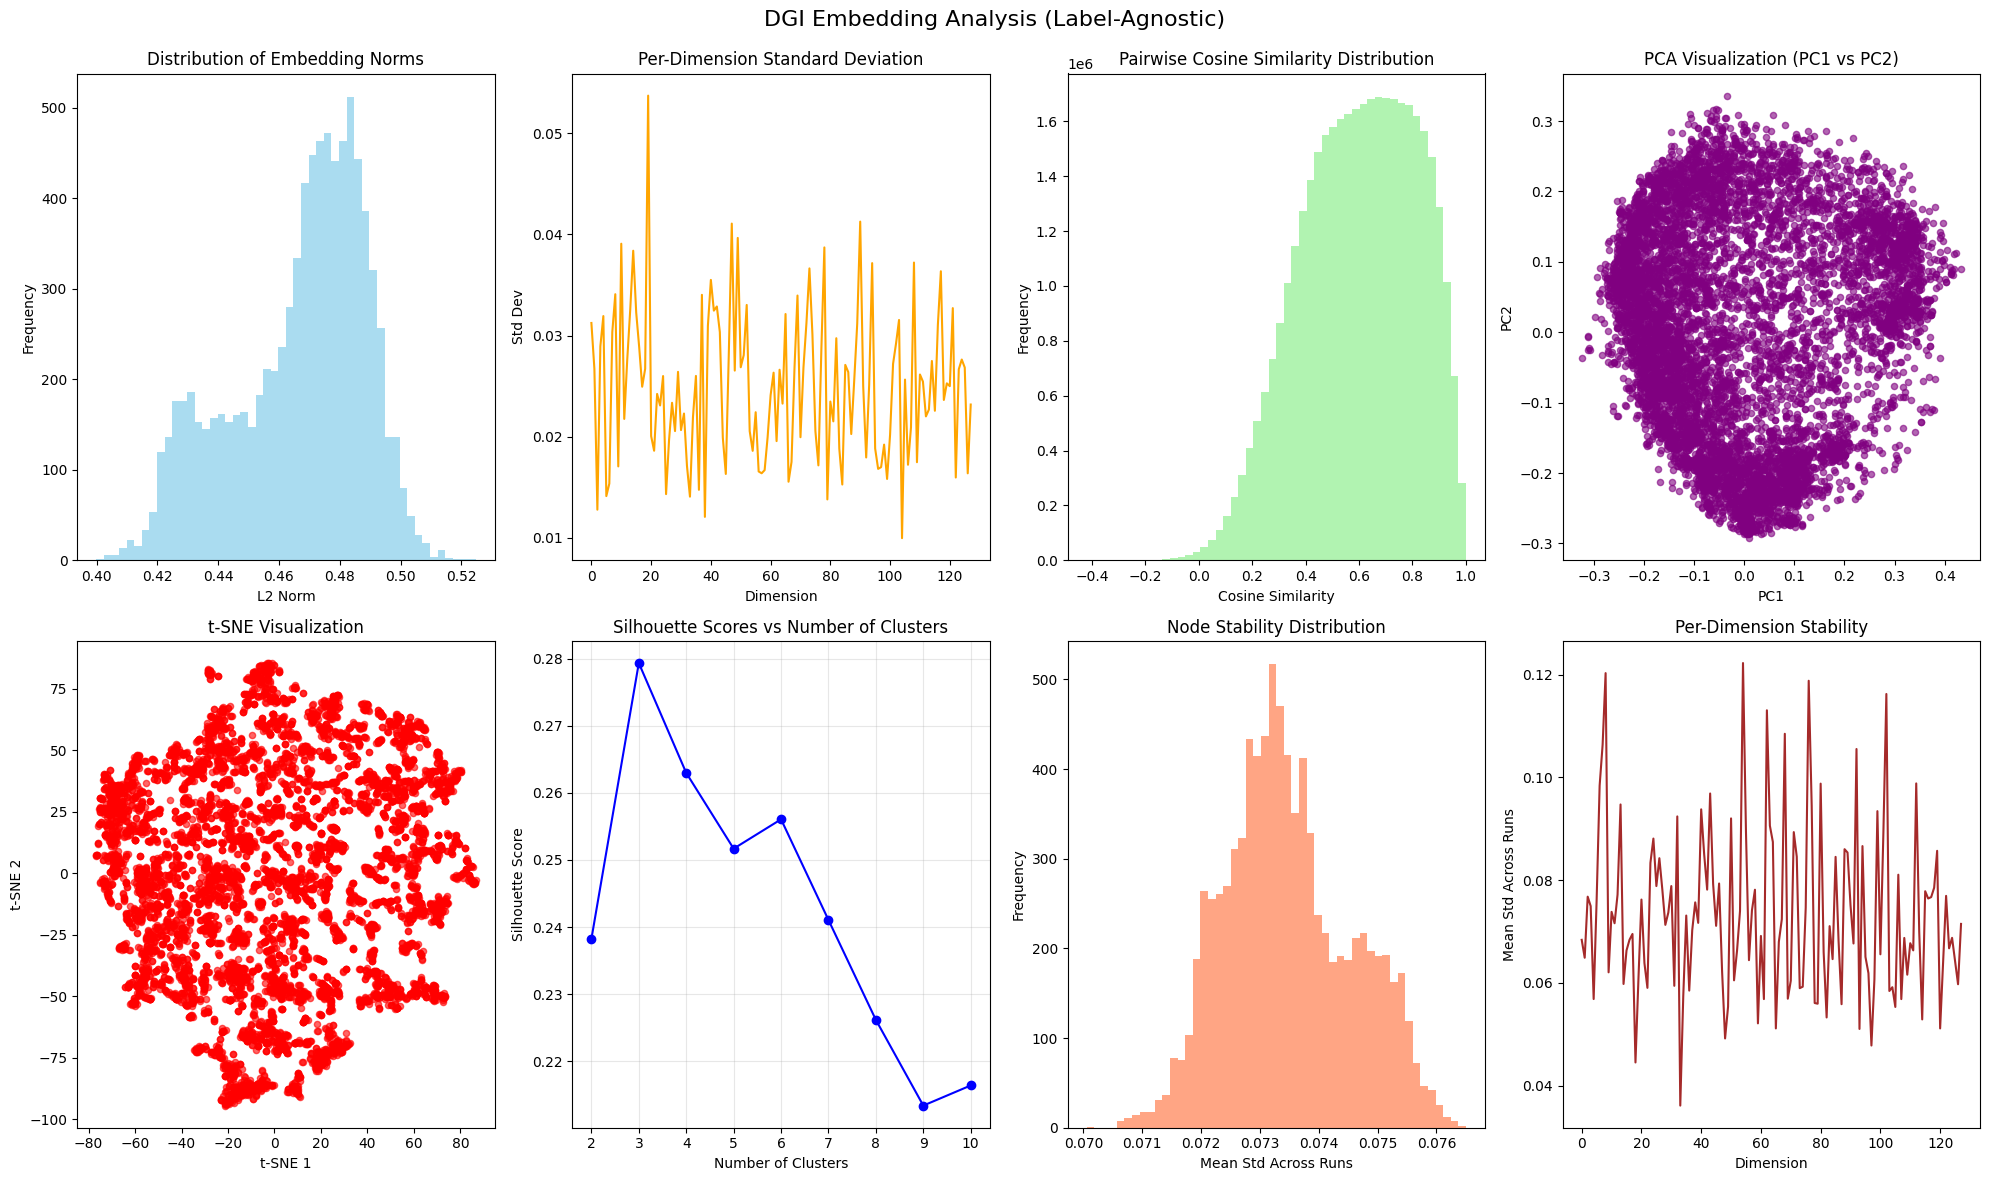

In [3]:
# Usage:
avg_embeddings = np.load('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/VasculaidKG/VasculaidKG/CuratedData/Proteins/PAD/Results/DGI/node_dgi_avg_embeddings.npy')
std_embeddings = np.load('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/VasculaidKG/VasculaidKG/CuratedData/Proteins/PAD/Results/DGI/node_dgi_std_embeddings.npy')  
results = analyze_dgi_embeddings(avg_embeddings, std_embeddings)

Load labels and other data of the graph 

In [4]:
import warnings
warnings.filterwarnings("ignore", message="An issue occurred while importing 'pyg-lib'")
warnings.filterwarnings("ignore", message="An issue occurred while importing 'torch-sparse'")
import torch
import pandas as pd
import numpy as np
import os
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import torch.optim as optim
import networkx as nx
from torch_geometric.utils import to_networkx
from torch.profiler import profile, record_function, ProfilerActivity
import torch.nn as nn
from torch_geometric.nn import GCNConv, BatchNorm, GATConv, GATv2Conv
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Change the working directory
os.chdir('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/VasculaidKG/VasculaidKG/CuratedData/Proteins/PAD/Scripts/')
#

# Load node and edge data
nodes_df = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/VasculaidKG/VasculaidKG/CuratedData/Proteins/PAD/CuratedData/LargestComponents/Nodes_with_properties_FC.csv')
edges_df = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/VasculaidKG/VasculaidKG/CuratedData/Proteins/PAD/CuratedData/LargestComponents/Edges_with_nodeproperties_FC.csv')
edges_df.insert(0, 'EdgeIndex', range(1, 1 + len(edges_df)))

# Drop unnecessary columns
nodes_df.drop(columns=['AAA', 'AMI', 'Stroke', 'HeartFailure', 'UniProt ID', 'Label'], inplace=True)

print(f"Nodes: {nodes_df.shape[0]}")
print(f"Edges: {edges_df.shape[0]}")

# Load pre-trained models
print("Loading ProtBERT model...")
#prot_tokenizer = AutoTokenizer.from_pretrained("Rostlab/prot_bert")
#prot_model = AutoModel.from_pretrained("Rostlab/prot_bert")
print("ProtBERT model loaded successfully!")

print("Loading BioBERT model...")
#bio_tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-v1.1")
#bio_model = AutoModel.from_pretrained("dmis-lab/biobert-v1.1")
print("BioBERT model loaded successfully!")

# Embedding functions (keeping your original functions)
def get_prot_embeddings(sequence, max_length=512):
    if pd.isnull(sequence):
        return None
    inputs = prot_tokenizer(sequence, return_tensors='pt', padding=True, truncation=True, max_length=max_length)
    with torch.no_grad():
        outputs = prot_model(**inputs)
    embeddings = outputs.last_hidden_state.mean(dim=1)
    return embeddings.numpy()

def get_ntseq_embeddings(sequence, max_length=512):
    if pd.isnull(sequence):
        return None
    inputs = prot_tokenizer(sequence, return_tensors='pt', padding=True, truncation=True, max_length=max_length)
    with torch.no_grad():
        outputs = prot_model(**inputs)
    embeddings = outputs.last_hidden_state.mean(dim=1)
    return embeddings.numpy()

def get_bio_embeddings(text, max_length=512):
    if pd.isnull(text):
        return None
    max_length = min(bio_tokenizer.model_max_length, max_length)
    inputs = bio_tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=max_length)
    with torch.no_grad():
        outputs = bio_model(**inputs)
    embeddings = outputs.last_hidden_state.mean(dim=1)
    return embeddings.numpy()

def get_label_embeddings(text, max_length=128):
    if pd.isnull(text):
        return None
    max_length = min(bio_tokenizer.model_max_length, max_length)
    inputs = bio_tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=max_length)
    with torch.no_grad():
        outputs = bio_model(**inputs)
    embeddings = outputs.last_hidden_state.mean(dim=1)
    return embeddings.numpy()

def get_batch_embeddings(sequences, embedding_function, batch_size=32, max_length=512):
    embeddings = []
    for i in range(0, len(sequences), batch_size):
        batch = sequences[i:i + batch_size]
        batch_embeddings = [embedding_function(seq, max_length) for seq in batch]
        if batch_embeddings:
            print(f"Shape of first embedding in batch {i // batch_size + 1}: {batch_embeddings[0].shape}")
        if any(embedding is None for embedding in batch_embeddings):
            print(f"Warning: None returned in batch {i // batch_size + 1}")
        embeddings.extend(batch_embeddings)
        print(f"Processing batch {i // batch_size + 1} of {len(sequences) // batch_size + 1}")
    return embeddings

# Prepare data
nodes_df = nodes_df.copy()
print('Processing embeddings and features...')

# Scale numeric features
scaler = StandardScaler()
numeric_features = ['Molecular Weight', 'AASEQ Length', 'NTSEQ Length']
nodes_df[numeric_features] = scaler.fit_transform(nodes_df[numeric_features])

# Convert numeric features to tensor
numeric_tensor = torch.tensor(nodes_df[numeric_features].values, dtype=torch.float)

# Load saved embeddings
aaseq_embeddings = torch.tensor(np.load('aaseq_embeddings.npy'), dtype=torch.float)
ntseq_embeddings = torch.tensor(np.load('ntseq_embeddings.npy'), dtype=torch.float)
function_embeddings = torch.tensor(np.load('function_embeddings.npy'), dtype=torch.float)

# Squeeze embeddings
aaseq_embeddings = aaseq_embeddings.squeeze(1)
ntseq_embeddings = ntseq_embeddings.squeeze(1)
function_embeddings = function_embeddings.squeeze(1)

# Concatenate all features
x = torch.cat([aaseq_embeddings, ntseq_embeddings, function_embeddings, numeric_tensor], dim=1)

# Prepare labels
labels_df = nodes_df[['PAD']].copy()  # Assuming PAD is your target column
labels_df.replace(0, -1, inplace=True)
labels = labels_df.applymap(lambda x: 1 if x == 1 else -1).values
labels = torch.tensor(labels, dtype=torch.float)

# Create masks
known_labels = labels_df.applymap(lambda x: x == 1).any(axis=1)
known_labels_indices = np.where(known_labels)[0]
train_indices = known_labels_indices
train_mask = np.zeros(len(labels_df), dtype=bool)
train_mask[train_indices] = True
test_mask = ~known_labels
test_indices = np.where(test_mask)[0]


Nodes: 8730
Edges: 29744
Loading ProtBERT model...
ProtBERT model loaded successfully!
Loading BioBERT model...
BioBERT model loaded successfully!
Processing embeddings and features...


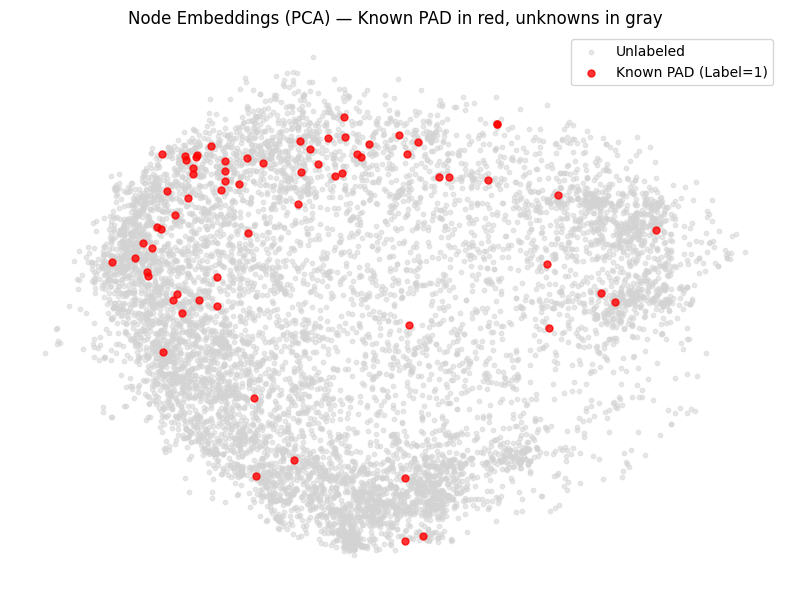

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Example: pick one
# reducer = TSNE(n_components=2, random_state=42)
reducer = PCA(n_components=2)

avg_embeddings = np.load('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/VasculaidKG/VasculaidKG/CuratedData/Proteins/PAD/Results/DGI/node_dgi_avg_embeddings.npy')
std_embeddings = np.load('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/VasculaidKG/VasculaidKG/CuratedData/Proteins/PAD/Results/DGI/node_dgi_std_embeddings.npy')  

emb_2d = reducer.fit_transform(avg_embeddings)

labels = labels.flatten()  # Make it shape (N,)
known_mask = labels == 1
unknown_mask = labels == -1

plt.figure(figsize=(8, 6))
plt.scatter(emb_2d[unknown_mask, 0], emb_2d[unknown_mask, 1],
            c='lightgray', s=10, alpha=0.5, label='Unlabeled')
plt.scatter(emb_2d[known_mask, 0], emb_2d[known_mask, 1],
            c='red', s=25, alpha=0.8, label='Known PAD (Label=1)')

plt.legend()
plt.title("Node Embeddings (PCA) — Known PAD in red, unknowns in gray")
plt.axis('off')
plt.tight_layout()
plt.show()



Embedding Stability (mean std across embedding dims):
GAE embedding std: 0.063396
VGAE embedding std: 0.063612


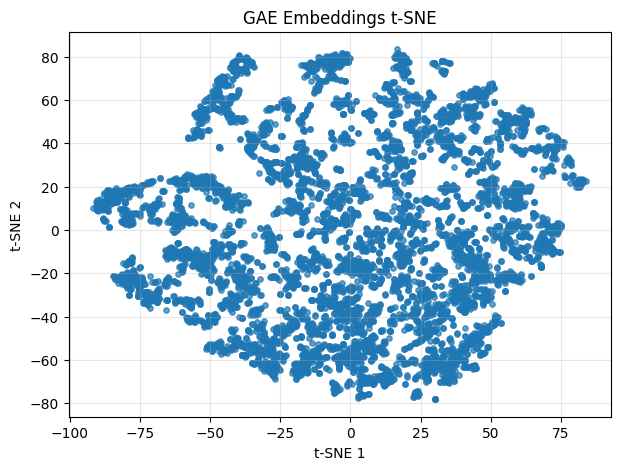

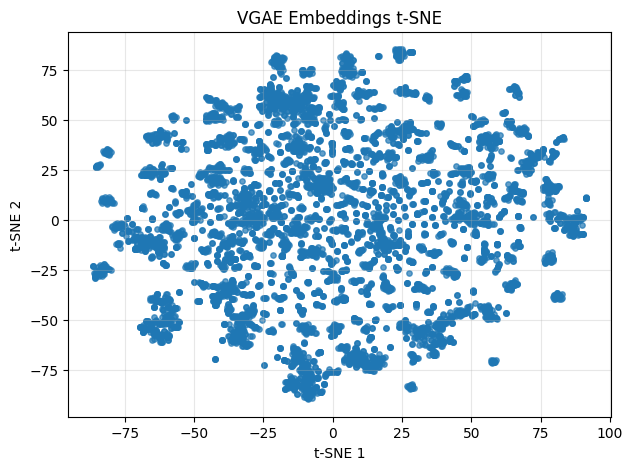

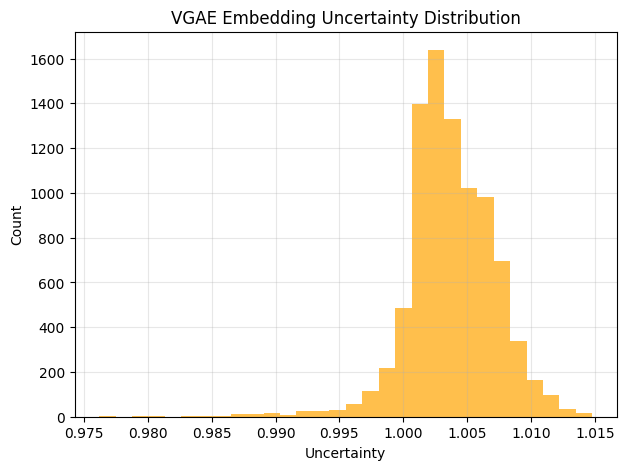

GAE similarity matrix shape: (8730, 8730)
VGAE similarity matrix shape: (8730, 8730)


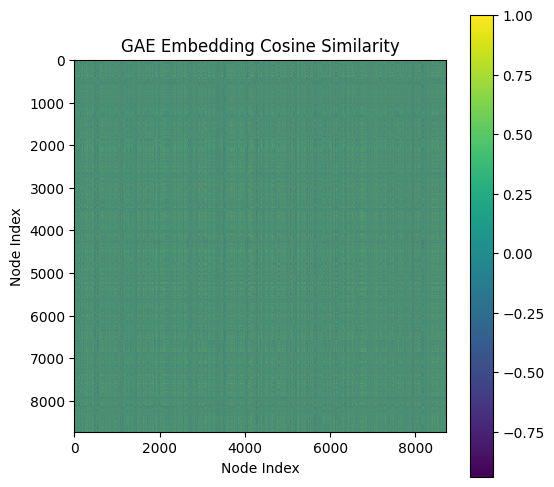

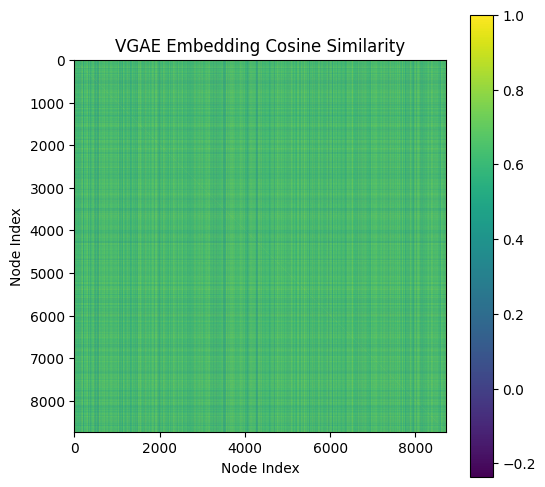

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

# Paths to saved files
gae_emb_path = '/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/VasculaidKG/VasculaidKG/CuratedData/Proteins/PAD/Results/GAE/gae_avg_embeddings.npy'
vgae_emb_path = '/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/VasculaidKG/VasculaidKG/CuratedData/Proteins/PAD/Results/GAE/vgae_avg_embeddings.npy'
gae_std_path = '/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/VasculaidKG/VasculaidKG/CuratedData/Proteins/PAD/Results/GAE/gae_embeddings_std.npy'
vgae_std_path = '/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/VasculaidKG/VasculaidKG/CuratedData/Proteins/PAD/Results/GAE/vgae_embeddings_std.npy'
vgae_uncertainty_path = '/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/VasculaidKG/VasculaidKG/CuratedData/Proteins/PAD/Results/GAE/vgae_uncertainty.npy'

# Load saved data
gae_embeds = np.load(gae_emb_path)
vgae_embeds = np.load(vgae_emb_path)

gae_std = np.load(gae_std_path)
vgae_std = np.load(vgae_std_path)

vgae_uncertainty = np.load(vgae_uncertainty_path)

# 1. Embedding Stability Check
print("Embedding Stability (mean std across embedding dims):")
print(f"GAE embedding std: {np.mean(gae_std):.6f}")
print(f"VGAE embedding std: {np.mean(vgae_std):.6f}")

# 2. t-SNE Visualization
def plot_tsne(embeddings, title):
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)//4))
    embeds_2d = tsne.fit_transform(embeddings)
    plt.figure(figsize=(7,5))
    plt.scatter(embeds_2d[:,0], embeds_2d[:,1], s=15, alpha=0.7)
    plt.title(title)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.grid(True, alpha=0.3)
    plt.show()

plot_tsne(gae_embeds, 'GAE Embeddings t-SNE')
plot_tsne(vgae_embeds, 'VGAE Embeddings t-SNE')

# 3. Uncertainty Analysis (VGAE only)
plt.figure(figsize=(7,5))
plt.hist(vgae_uncertainty.mean(axis=1), bins=30, alpha=0.7, color='orange')
plt.title('VGAE Embedding Uncertainty Distribution')
plt.xlabel('Uncertainty')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Similarity Matrix Check (Cosine similarity)
gae_sim = cosine_similarity(gae_embeds)
vgae_sim = cosine_similarity(vgae_embeds)

print(f"GAE similarity matrix shape: {gae_sim.shape}")
print(f"VGAE similarity matrix shape: {vgae_sim.shape}")

# Optional: Visualize similarity heatmaps
def plot_similarity_heatmap(sim_matrix, title):
    plt.figure(figsize=(6,6))
    plt.imshow(sim_matrix, cmap='viridis')
    plt.colorbar()
    plt.title(title)
    plt.xlabel('Node Index')
    plt.ylabel('Node Index')
    plt.show()

plot_similarity_heatmap(gae_sim, 'GAE Embedding Cosine Similarity')
plot_similarity_heatmap(vgae_sim, 'VGAE Embedding Cosine Similarity')
